In [1]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import firtez_dz as frz
from astropy.io import fits
from matplotlib.colors import CenteredNorm, TwoSlopeNorm
import muram as mio
import matplotlib.colors as colors

In [2]:
plt.rc('text', usetex = False)

## read

In [3]:
atm = fits.open('/dat/xenosh/muram_plage_pore/smaller_cubes/muram_nx300_ny300_nz200_d605_020000_to_039000_addrho.fits')[0].data

In [4]:
atm_tau = fits.open('/dat/xenosh/muram_plage_pore/smaller_cubes/muram_nx300_ny300_nz200_d605_020000_to_039000_tau_addrho.fits')[0].data

In [12]:
atm.shape

(20, 9, 300, 300, 200)

In [71]:
atm_tau.shape

(20, 10, 300, 300, 36)

In [9]:
np.max(atm[:,0,:,:,0])

3.5244760513305664

In [8]:
np.min(atm[:,0,:,:,0])

-0.7994557023048401

In [19]:
np.max(atm[:,0,:,:,:-1])

4.335824966430664

In [17]:
atm_tau[0,0,0,0,:]

array([ 1. ,  0.9,  0.8,  0.7,  0.6,  0.5,  0.4,  0.3,  0.2,  0.1,  0. ,
       -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1. , -1.1,
       -1.2, -1.3, -1.4, -1.5, -1.6, -1.7, -1.8, -1.9, -2. , -2.1, -2.2,
       -2.3, -2.4, -2.5], dtype='>f8')

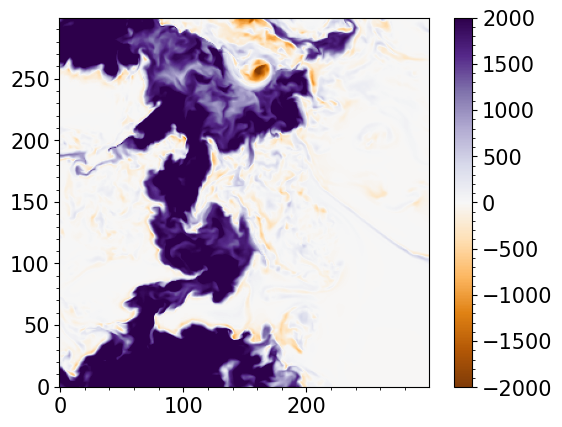

In [27]:
plt.imshow(slice[280,850:1150,650:950].T,origin='lower',cmap='PuOr',vmax=2000,vmin=-2000)
plt.colorbar()

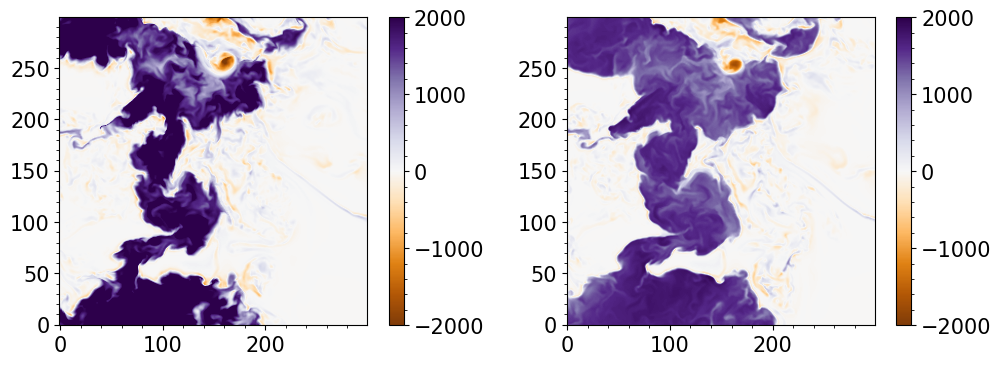

In [29]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.imshow(atm_tau[6,8,:,:,10].T,origin='lower',cmap='PuOr',vmax=2000,vmin=-2000)
plt.colorbar()
plt.subplot(122)
plt.imshow(atm[6,8,:,:,100].T,origin='lower',cmap='PuOr',vmax=2000,vmin=-2000)
plt.colorbar()


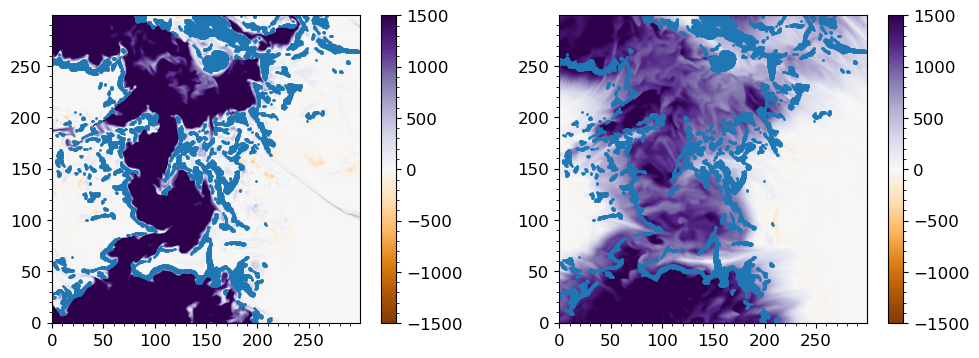

In [185]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.imshow(atm_tau[6,8,:,:,10].T,origin='lower',cmap='PuOr',vmax=1500,vmin=-1500)
plt.colorbar()
plt.scatter(oppo[:,0],oppo[:,1],s=1)
plt.subplot(122)
plt.imshow(atm_tau[6,8,:,:,30].T,origin='lower',cmap='PuOr',vmax=1500,vmin=-1500)
plt.colorbar()
plt.scatter(oppo[:,0],oppo[:,1],s=1)

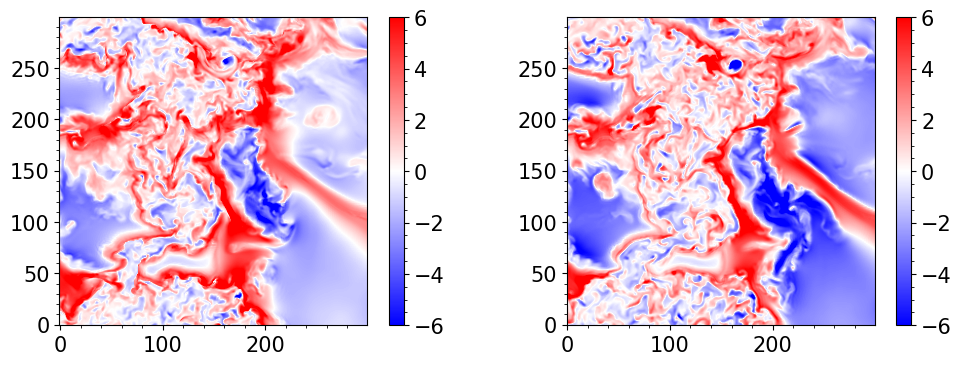

In [19]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.imshow(atm_tau[6,5,:,:,10].T/1e5,origin='lower',cmap='bwr',vmax=6,vmin=-6)
plt.colorbar()
plt.subplot(122)
plt.imshow(atm[6,5,:,:,100].T/1e5,origin='lower',cmap='bwr',vmax=6,vmin=-6)
plt.colorbar()


In [5]:
B_tau=np.sqrt(atm_tau[:,6,:,:,:]**2+atm_tau[:,7,:,:,:]**2+atm_tau[:,8,:,:,:]**2)

In [6]:
qs = np.argwhere(B_tau[6,:,:,10] < 100)
core = np.argwhere(B_tau[6,:,:,10] > 1000)

In [7]:
c3 = B_tau[:,:,30] > 300
c4 = B_tau[:,:,30] - B_tau[:,:,10] > 100
c5 = B_tau[:,:,10] < 1000
canopy = np.argwhere(c5 & c3 & c4)

In [8]:
c6 = atm_tau[6,8,:,:,10] < -50
c7 = B_tau[6,:,:,30] > 300
oppo = np.argwhere(c6 & c7)

In [147]:
oppo.shape

(9649, 2)

## vorticity

$\vec \omega = \nabla \times \vec v$ \
\
$\nabla \times \vec v = (\frac{\partial v_z}{\partial y} - \frac{\partial v_y}{\partial z}) \hat i + (\frac{\partial v_x}{\partial z} - \frac{\partial v_z}{\partial x}) \hat j + (\frac{\partial v_y}{\partial x} - \frac{\partial v_x}{\partial y}) \hat k$ \
\
$\omega_H = \sqrt{\omega_x^2 + \omega_y^2}$ 

In [5]:
wx = np.gradient(-atm[:,5,:,:,:]/1e5,6.5,axis=2) - np.gradient(atm[:,4,:,:,:]/1e5,6.5,axis=3)
wy = np.gradient(atm[:,3,:,:,:]/1e5,6.5,axis=3) - np.gradient(-atm[:,5,:,:,:]/1e5,6.5,axis=1)
wz = np.gradient(atm[:,4,:,:,:]/1e5,6.5,axis=1) - np.gradient(atm[:,3,:,:,:]/1e5,6.5,axis=2)

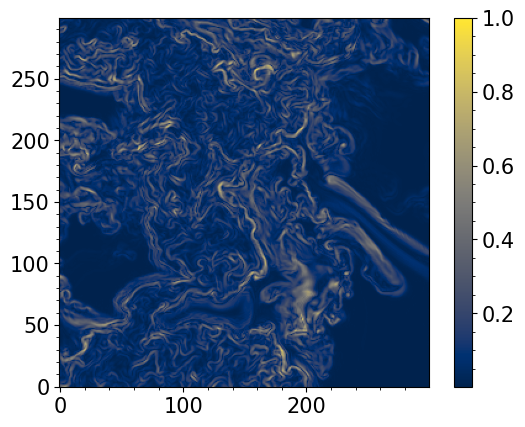

In [8]:
plt.imshow(np.sqrt(wx**2+wy**2)[6,:,:,95].T,origin='lower',cmap='cividis',vmax=1)
plt.colorbar()

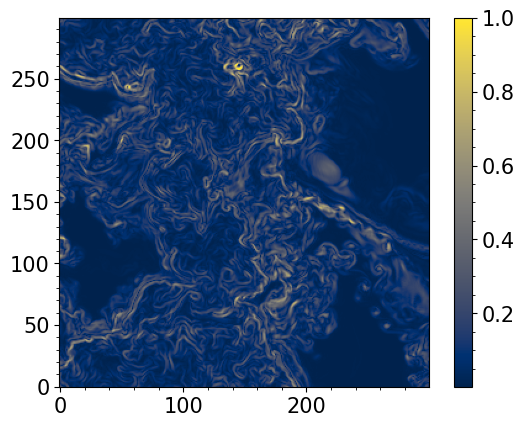

In [9]:
plt.imshow(np.sqrt(wx**2+wy**2)[8,:,:,95].T,origin='lower',cmap='cividis',vmax=1)
plt.colorbar()

In [70]:
plt.rc('font', size = 12)

Text(0.5, 0, 'x [km]')

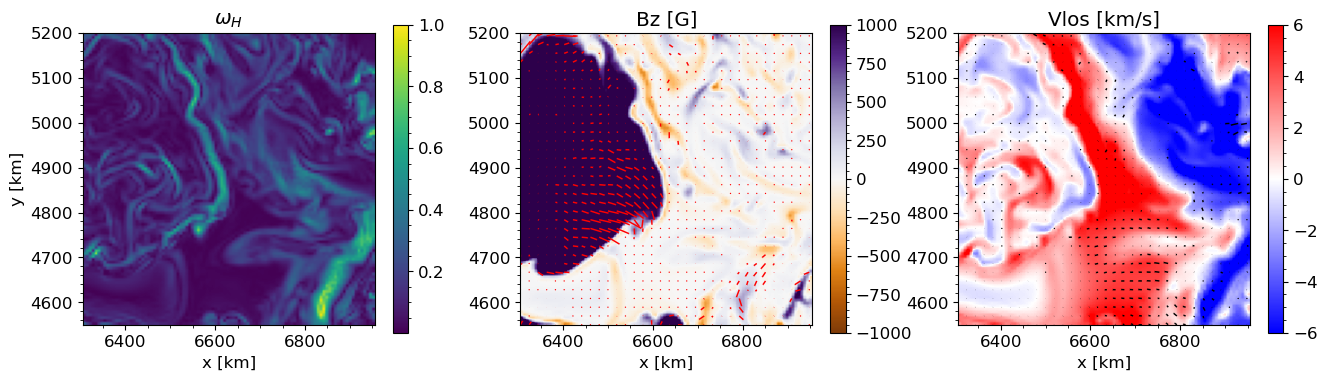

In [75]:
plt.figure(figsize=(16,5))
plt.subplot(131)
plt.imshow(np.sqrt(wx**2+wy**2)[6,120:220,50:150,100].T,origin='lower',vmax=1,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.title(r'$\omega_H$')
plt.ylabel('y [km]')
plt.xlabel('x [km]')
plt.subplot(132)
plt.imshow(atm[6,8,120:220,50:150,100].T,origin='lower',cmap='PuOr',vmax=1000,vmin=-1000,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
stride = 3
xsize,ysize = atm[6,8,120:220,50:150,100].shape
xmax = int(xsize/stride)+1
ymax = int(ysize/stride)+1
X,Y = np.meshgrid(970*6.5+stride*np.arange(0,xmax)*6.5,700*6.5+stride*np.arange(0,ymax)*6.5)
plt.quiver(X,Y,atm[6,6,120:220:stride,50:150:stride,100].T,atm[6,7,120:220:stride,50:150:stride,100].T,width=.005, headwidth=0,color='r')
plt.title('Bz [G]')
plt.xlabel('x [km]')
plt.subplot(133)
plt.imshow(atm[6,5,120:220,50:150,100].T/1e5,origin='lower',cmap='bwr',vmax=6,vmin=-6,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.quiver(X,Y,atm[6,3,120:220:stride,50:150:stride,100].T/1e5,atm[6,4,120:220:stride,50:150:stride,100].T/1e5,width=.005, headwidth=0)
plt.title('Vlos [km/s]')
plt.xlabel('x [km]')
#plt.tight_layout()

Text(0.5, 0, 'x [km]')

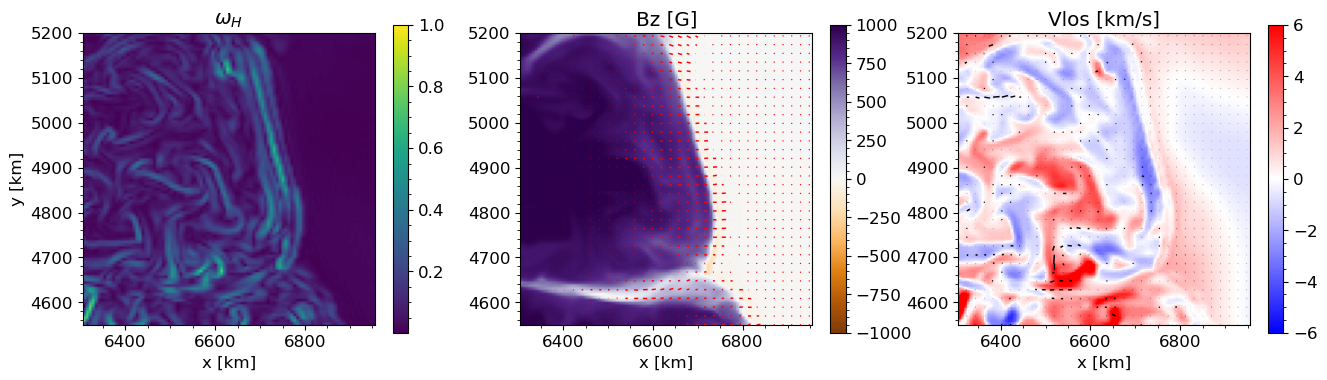

In [86]:
z = 135
plt.figure(figsize=(16,5))
plt.subplot(131)
plt.imshow(np.sqrt(wx**2+wy**2)[6,120:220,50:150,z].T,origin='lower',vmax=1,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.title(r'$\omega_H$')
plt.ylabel('y [km]')
plt.xlabel('x [km]')
plt.subplot(132)
plt.imshow(atm[6,8,120:220,50:150,130].T,origin='lower',cmap='PuOr',vmax=1000,vmin=-1000,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
stride = 3
xsize,ysize = atm[6,8,120:220,50:150,100].shape
xmax = int(xsize/stride)+1
ymax = int(ysize/stride)+1
X,Y = np.meshgrid(970*6.5+stride*np.arange(0,xmax)*6.5,700*6.5+stride*np.arange(0,ymax)*6.5)
plt.quiver(X,Y,atm[6,6,120:220:stride,50:150:stride,z].T,atm[6,7,120:220:stride,50:150:stride,z].T,width=.005, headwidth=0,color='r')
plt.title('Bz [G]')
plt.xlabel('x [km]')
plt.subplot(133)
plt.imshow(atm[6,5,120:220,50:150,z].T/1e5,origin='lower',cmap='bwr',vmax=6,vmin=-6,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.quiver(X,Y,atm[6,3,120:220:stride,50:150:stride,z].T/1e5,atm[6,4,120:220:stride,50:150:stride,z].T/1e5,width=.005, headwidth=0)
plt.title('Vlos [km/s]')
plt.xlabel('x [km]')
#plt.subplot(224)
#plt.imshow(S[6,120:220,50:150,z].T/1e9,origin='lower',cmap='coolwarm',vmin=-10,vmax=10,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
#plt.colorbar(shrink=0.8)
#plt.tight_layout()

Text(0.5, 0, 'x [km]')

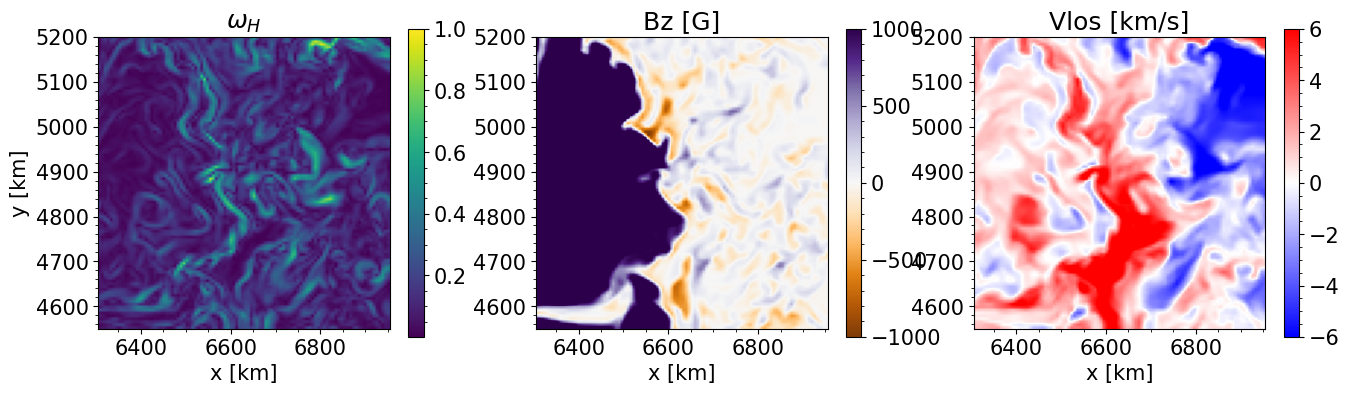

In [29]:
plt.figure(figsize=(16,5))
plt.subplot(131)
plt.imshow(np.sqrt(wx**2+wy**2)[16,120:220,50:150,100].T,origin='lower',vmax=1,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.title(r'$\omega_H$')
plt.ylabel('y [km]')
plt.xlabel('x [km]')
plt.subplot(132)
plt.imshow(atm[16,8,120:220,50:150,100].T,origin='lower',cmap='PuOr',vmax=1000,vmin=-1000,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.title('Bz [G]')
plt.xlabel('x [km]')
plt.subplot(133)
plt.imshow(atm[16,5,120:220,50:150,100].T/1e5,origin='lower',cmap='bwr',vmax=6,vmin=-6,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.title('Vlos [km/s]')
plt.xlabel('x [km]')
#plt.tight_layout()

## Poynting flux

$S_z = \frac{1}{4 \pi}[v_z B^2_h - (v_h \cdot \bm{B_h})B_z] = \frac{1}{4 \pi}[v_z B^2_h -(v_x*B_x +v_y*B_y)B_z] $

In [6]:
S1 = (-atm[:,5,:,:,:]*(atm[:,6,:,:,:]**2+atm[:,7,:,:,:]**2))/(4*np.pi)
S2 = -((atm[:,3,:,:,:]*atm[:,6,:,:,:]+atm[:,4,:,:,:]*atm[:,7,:,:,:])*atm[:,8,:,:,:] )/(4*np.pi)
S = S1 + S2

In [7]:
S1_tau = (-atm_tau[:,5,:,:,:]*(atm_tau[:,6,:,:,:]**2+atm_tau[:,7,:,:,:]**2))/(4*np.pi)
S2_tau = -((atm_tau[:,3,:,:,:]*atm_tau[:,6,:,:,:]+atm_tau[:,4,:,:,:]*atm_tau[:,7,:,:,:])*atm_tau[:,8,:,:,:] )/(4*np.pi)
S_tau = S1_tau + S2_tau

In [37]:
768-650

118

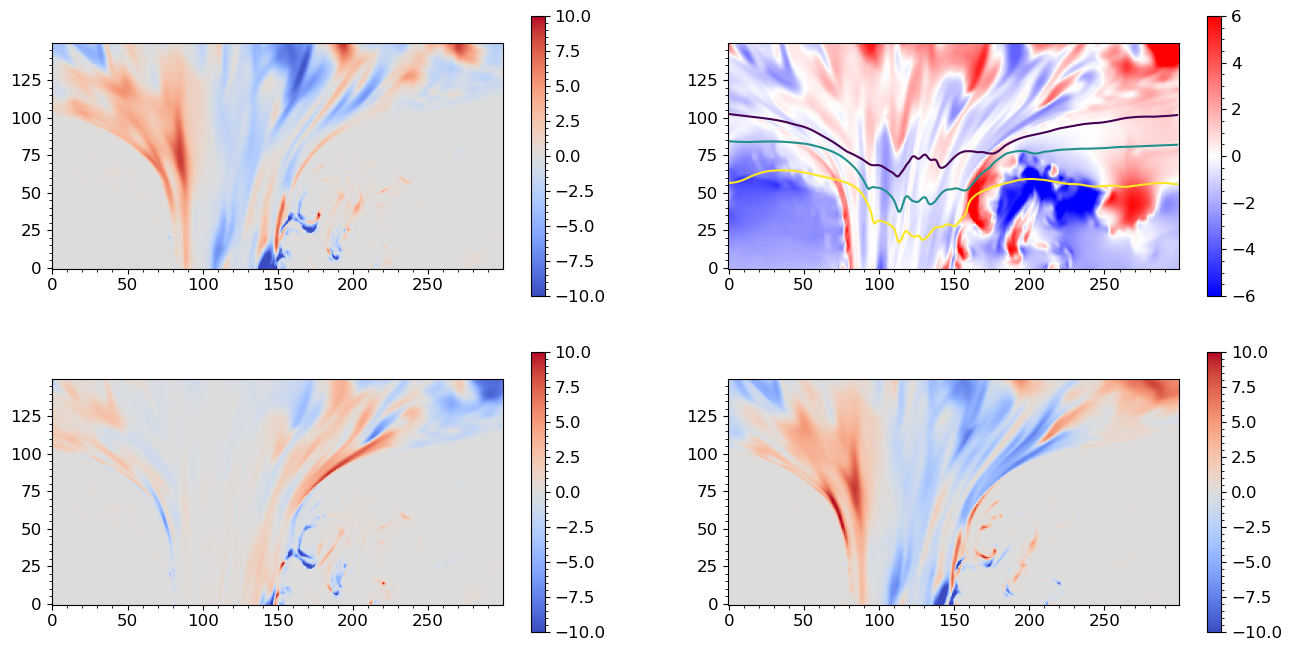

In [79]:
plt.figure(figsize=(16,8))
plt.subplot(221)
plt.imshow(S[6,:,118,50:].T/1e9,origin='lower',cmap='coolwarm',vmax=10,vmin=-10)
plt.colorbar()
plt.subplot(222)
plt.imshow(atm[6,5,:,118,50:].T/1e5,origin='lower',cmap='bwr',vmin=-6,vmax=6)
plt.colorbar()
plt.contour(atm[10,0,:,118,50:].T,levels=['-2','-1','0'])
plt.subplot(223)
plt.imshow(S1[6,:,118,50:].T/1e9,origin='lower',cmap='coolwarm',vmax=10,vmin=-10)
plt.colorbar()
plt.subplot(224)
plt.imshow(S2[6,:,118,50:].T/1e9,origin='lower',cmap='coolwarm',vmax=10,vmin=-10)
plt.colorbar()

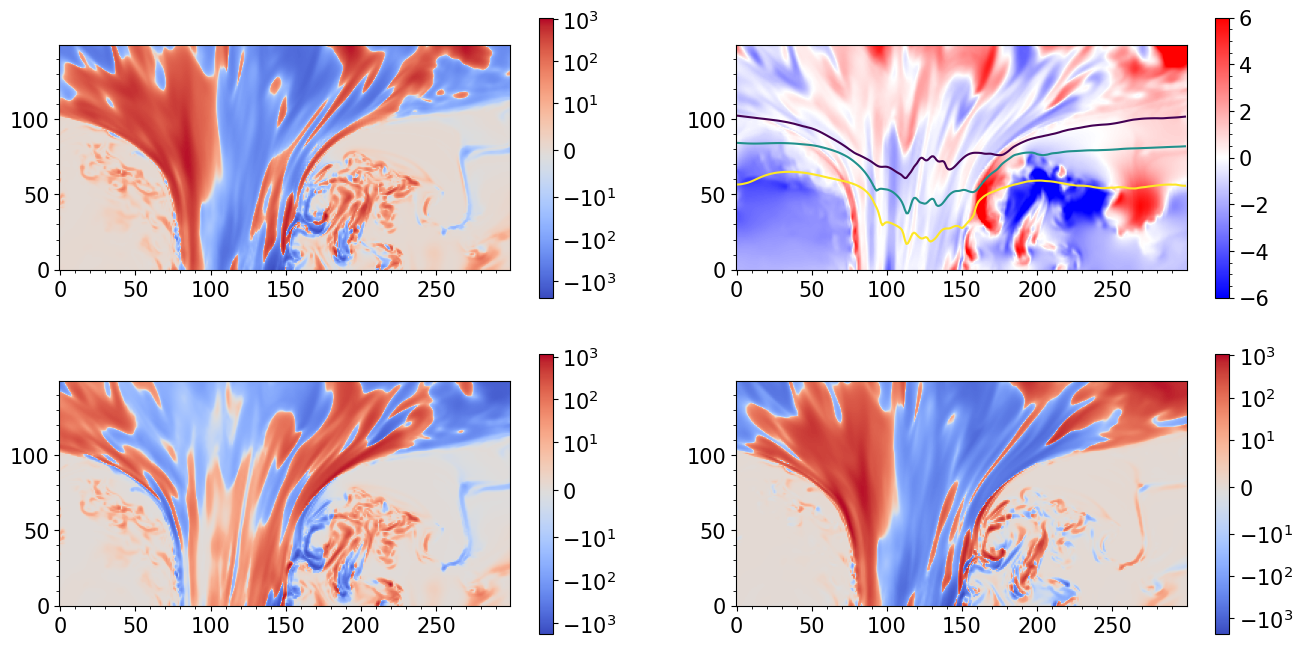

In [37]:
plt.figure(figsize=(16,8))
plt.subplot(221)
plt.imshow(S[6,:,118,50:].T/1e7,origin='lower',cmap='coolwarm',norm=colors.SymLogNorm(linthresh=10))
plt.colorbar()
plt.subplot(222)
plt.imshow(atm[6,5,:,118,50:].T/1e5,origin='lower',cmap='bwr',vmin=-6,vmax=6)
plt.colorbar()
plt.contour(atm[10,0,:,118,50:].T,levels=['-2','-1','0'])
plt.subplot(223)
plt.imshow(S1[6,:,118,50:].T/1e7,origin='lower',cmap='coolwarm',norm=colors.SymLogNorm(linthresh=10))
plt.colorbar()
plt.subplot(224)
plt.imshow(S2[6,:,118,50:].T/1e7,origin='lower',cmap='coolwarm',norm=colors.SymLogNorm(linthresh=10))
plt.colorbar()

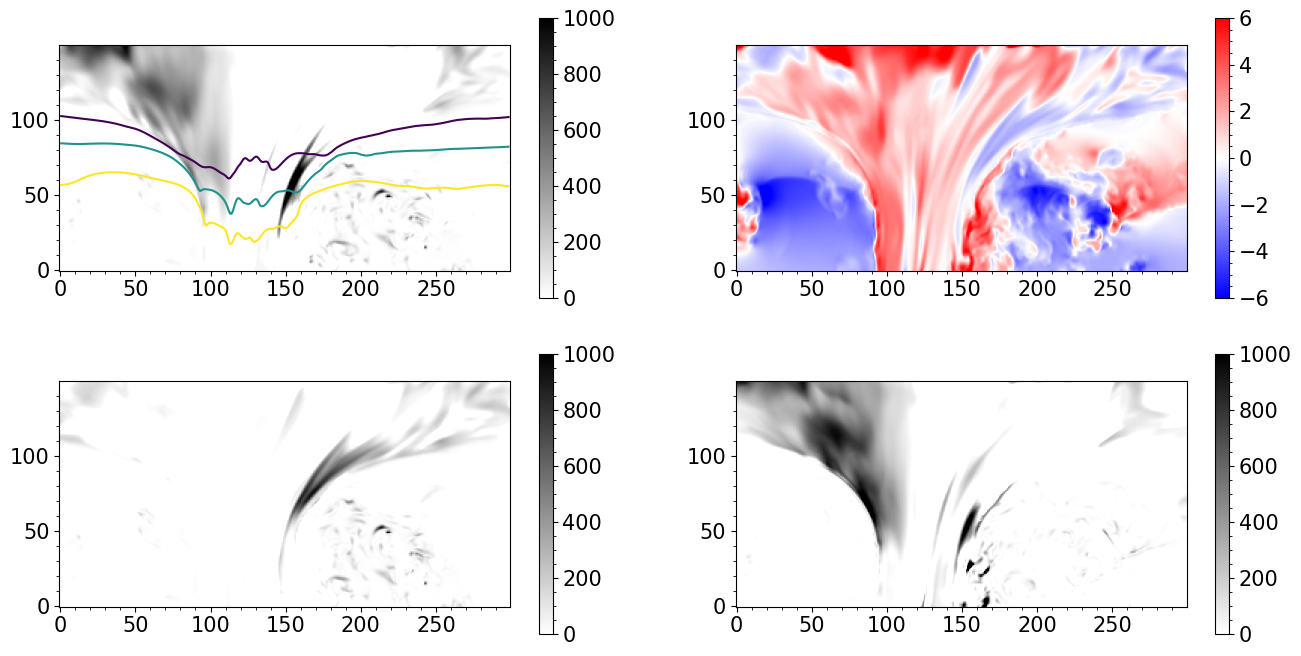

In [38]:
plt.figure(figsize=(16,8))
plt.subplot(221)
plt.imshow(S[10,:,118,50:].T/1e7,origin='lower',cmap='binary',vmax=1000,vmin=-000)
plt.colorbar()
plt.contour(atm[10,0,:,118,50:].T,levels=['-2','-1','0'])
plt.subplot(222)
plt.imshow(atm[10,5,:,118,50:].T/1e5,origin='lower',cmap='bwr',vmin=-6,vmax=6)
plt.colorbar()
plt.subplot(223)
plt.imshow(S1[10,:,118,50:].T/1e7,origin='lower',cmap='binary',vmax=1000,vmin=-000)
plt.colorbar()
plt.subplot(224)
plt.imshow(S2[10,:,118,50:].T/1e7,origin='lower',cmap='binary',vmax=1000,vmin=-000)
plt.colorbar()

In [32]:
mask = np.argwhere(np.abs(atm[6,8,:,:,95])> 50) 

In [33]:
mask.shape

(54423, 2)

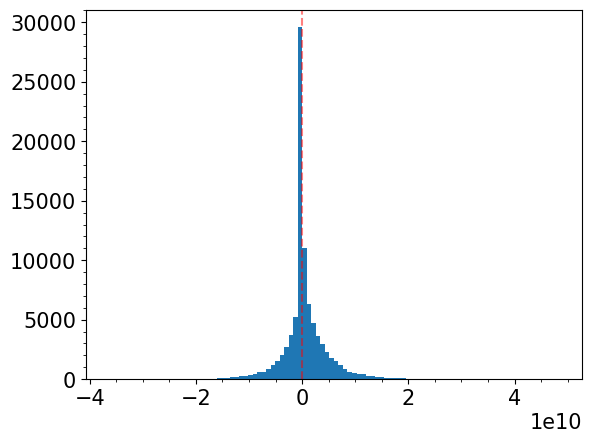

0.5520831247852552


In [54]:
plt.hist(S_tau[6,:,:,30].flatten(),bins=100)
plt.axvline(0,c='r',alpha=0.5,ls='--')
plt.show()
print(np.mean(S_tau[6,:,:,30])/1E9)

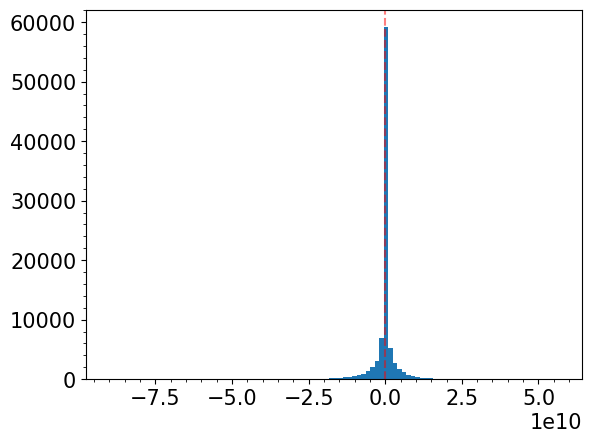

-0.15823521810029176


In [ ]:
plt.hist(S_tau[6,:,:,10].flatten(),bins=100)
plt.axvline(0,c='r',alpha=0.5,ls='--')
plt.show()
print(np.mean(S_tau[6,:,:,10])/1E9)

In [12]:
tau = np.linspace(-2.5,1,36)[::-1]

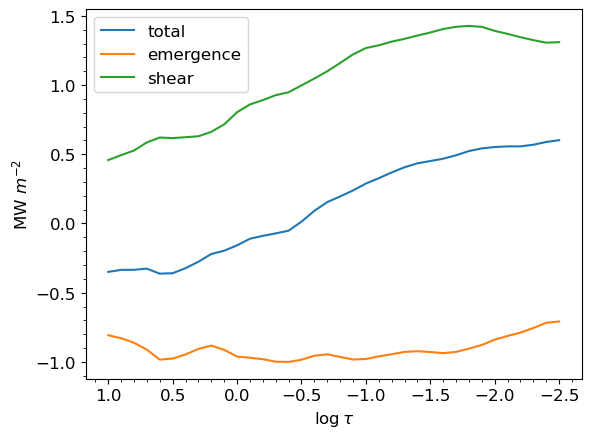

In [113]:
plt.plot(tau,np.mean(S_tau[6,:,:,:],axis=(0,1))/1E9,label='total')
plt.plot(tau,np.mean(S1_tau[6,:,:,:],axis=(0,1))/1E9,label='emergence')
plt.plot(tau,np.mean(S2_tau[6,:,:,:],axis=(0,1))/1E9,label='shear')
plt.legend()
plt.ylabel(r'MW $m^{-2}$')
plt.xlabel(r'$\log \tau$')
plt.gca().invert_xaxis()

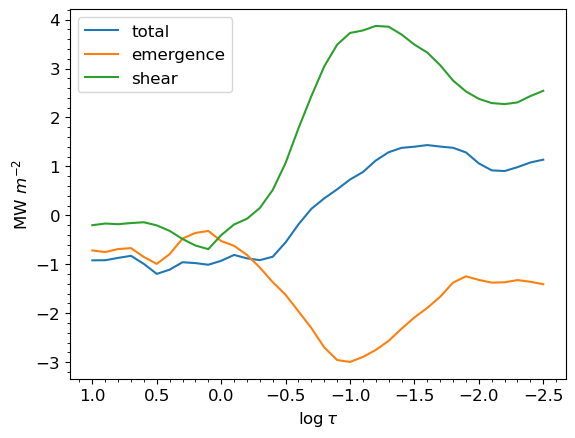

In [137]:
plt.plot(tau,np.mean(S_tau[6,oppo[:,0],oppo[:,1],:],axis=0)/1E9,label='total')
plt.plot(tau,np.mean(S1_tau[6,oppo[:,0],oppo[:,1],:],axis=0)/1E9,label='emergence')
plt.plot(tau,np.mean(S2_tau[6,oppo[:,0],oppo[:,1],:],axis=0)/1E9,label='shear')
plt.legend()
plt.ylabel(r'MW $m^{-2}$')
plt.xlabel(r'$\log \tau$')
plt.gca().invert_xaxis()

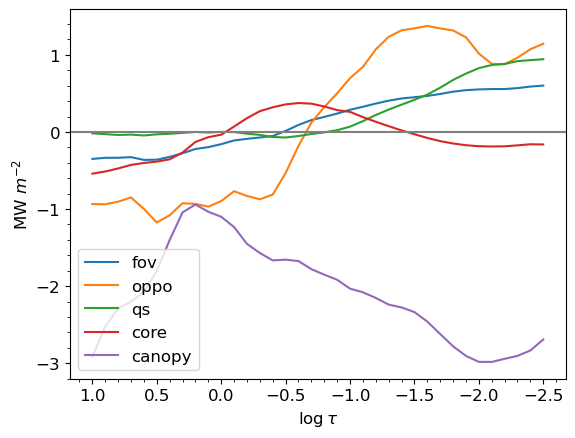

In [153]:
plt.plot(tau,np.mean(S_tau[6,:,:,:],axis=(0,1))/1E9,label='fov')
plt.plot(tau,np.mean(S_tau[6,oppo[:,0],oppo[:,1],:],axis=0)/1E9,label='oppo')
plt.plot(tau,np.mean(S_tau[6,qs[:,0],qs[:,1],:],axis=0)/1E9,label='qs')
plt.plot(tau,np.mean(S_tau[6,core[:,0],core[:,1],:],axis=0)/1E9,label='core')
plt.plot(tau,np.mean(S_tau[6,canopy[:,0],canopy[:,1],:],axis=0)/1E9,label='canopy')
plt.legend()
plt.ylabel(r'MW $m^{-2}$')
plt.xlabel(r'$\log \tau$')
plt.gca().invert_xaxis()
plt.axhline(0,c='gray')

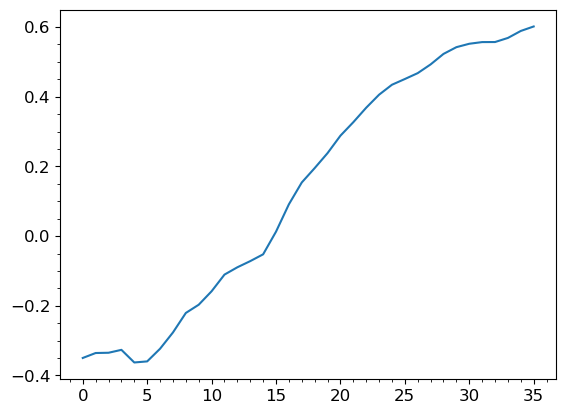

In [108]:
plt.plot(np.mean(S_tau[6,:,:,:],axis=(0,1))/1E9)

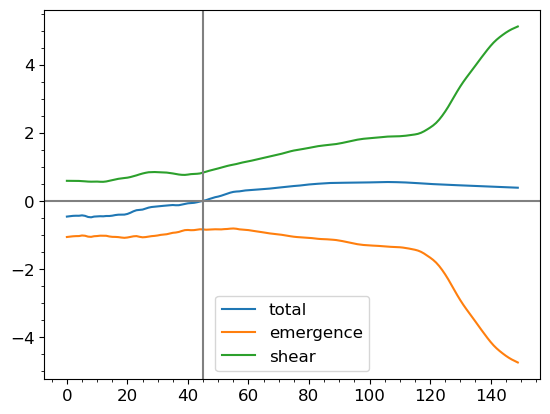

In [120]:
plt.plot(np.mean(S[6,:,:,50:],axis=(0,1))/1E9,label='total')
plt.plot(np.mean(S1[6,:,:,50:],axis=(0,1))/1E9,label='emergence')
plt.plot(np.mean(S2[6,:,:,50:],axis=(0,1))/1E9,label='shear')
plt.legend()
plt.axhline(0,c='gray')
plt.axvline(45,c='gray')

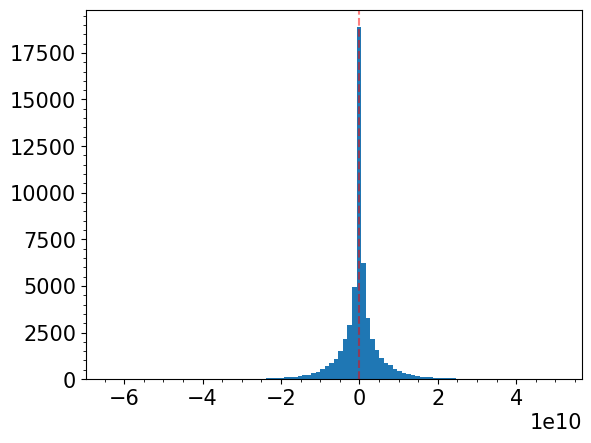

In [34]:
plt.hist(S[6,mask[:,0],mask[:,1],95].flatten(),bins=100)
plt.axvline(0,c='r',alpha=0.5,ls='--')
plt.show()

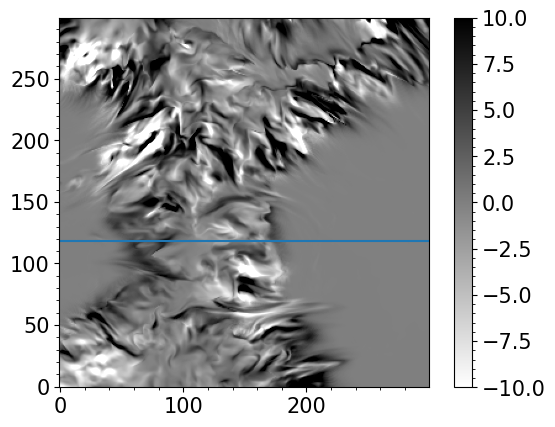

In [51]:
plt.imshow(S_tau[6,:,:,30].T/1e9,origin='lower',cmap='binary',vmax=10,vmin=-10)
plt.colorbar()
plt.axhline(118)

In [166]:
(700-381)/28.6

11.153846153846153

In [186]:
x1 = 120
x2 = x1 + 100
y1 = 50
y2 = y1 + 100

plt.figure(figsize=(6,20))
plt.subplot(411)
plt.imshow(S[4,x1:x2,y1:y2,131].T/1e9,origin='lower',cmap='RdBu',extent=[(x1+850)*6.5,(x2+850)*6.5,(y1+650)*6.5,(y2+650)*6.5],vmax=10,vmin=-10)
plt.colorbar()
plt.title('Sz [MW m^-2]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(412)
plt.imshow(S1[6,x1:x2,y1:y2,131].T/1e9,origin='lower',cmap='RdBu',extent=[(x1+850)*6.5,(x2+850)*6.5,(y1+650)*6.5,(y2+650)*6.5],vmax=10,vmin=-10)
plt.colorbar()
plt.title('Sz [MW m^-2]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(413)
plt.imshow(S1[8,x1:x2,y1:y2,131].T/1e9,origin='lower',cmap='RdBu',extent=[(x1+850)*6.5,(x2+850)*6.5,(y1+650)*6.5,(y2+650)*6.5],vmax=10,vmin=-10)
plt.colorbar()
plt.title('Sz [MW m^-2]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(414)
plt.imshow(S1[10,x1:x2,y1:y2,131].T/1e9,origin='lower',cmap='RdBu',extent=[(x1+850)*6.5,(x2+850)*6.5,(y1+650)*6.5,(y2+650)*6.5],vmax=10,vmin=-10)
plt.colorbar()
plt.title('Sz [MW m^-2]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.clf()

<Figure size 600x2000 with 0 Axes>

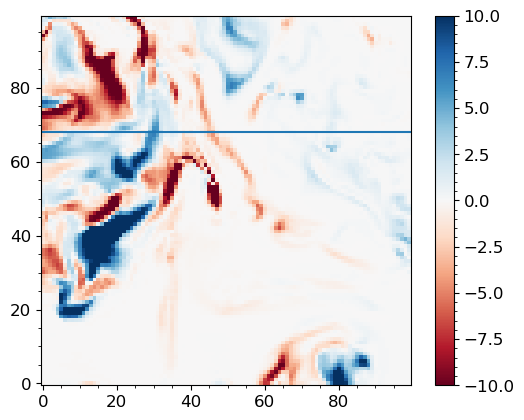

In [168]:
plt.imshow(S_tau[6,120:220,50:150,10].T/1e9,origin='lower',cmap='RdBu',vmax=10,vmin=-10)
plt.colorbar()
plt.axhline(118-50)

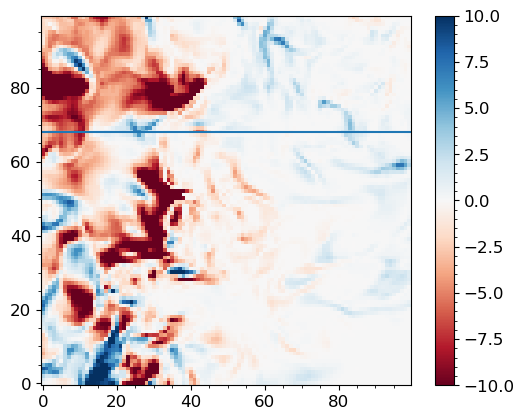

In [167]:
plt.imshow(S_tau[11,120:220,50:150,10].T/1e9,origin='lower',cmap='RdBu',vmax=10,vmin=-10)
plt.colorbar()
plt.axhline(118-50)

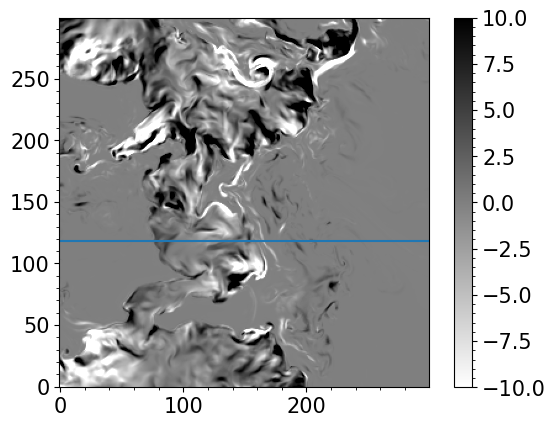

In [41]:
plt.imshow(S[6,:,:,95].T/1e9,origin='lower',cmap='binary',vmax=10,vmin=-10)
plt.colorbar()
plt.axhline(118)

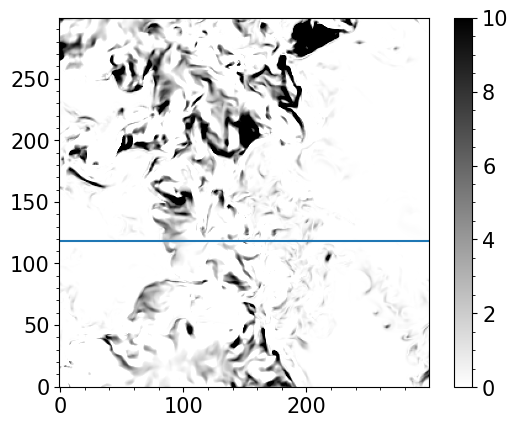

In [44]:
plt.imshow(S[8,:,:,95].T/1e9,origin='lower',cmap='binary',vmax=10,vmin=-0)
plt.colorbar()
plt.axhline(118)

In [54]:
np.mean(atm[8,0,:,:,50:150],axis=(0,1))

array([ 2.64504652,  2.60245284,  2.55959402,  2.51648703,  2.47312653,
        2.42948414,  2.38550912,  2.34114635,  2.2963573 ,  2.25111519,
        2.20537394,  2.15908534,  2.11227394,  2.06507459,  2.01764252,
        1.97006616,  1.92233621,  1.87442094,  1.82628539,  1.77789045,
        1.72914516,  1.67986142,  1.6298883 ,  1.57922929,  1.52798658,
        1.47627107,  1.42412809,  1.37156777,  1.3187347 ,  1.26570277,
        1.21233745,  1.15850735,  1.10410556,  1.04901993,  0.99320889,
        0.93670209,  0.87951714,  0.82156806,  0.76276693,  0.70308487,
        0.6425593 ,  0.58128429,  0.51931369,  0.45653777,  0.39255729,
        0.32685201,  0.2589629 ,  0.18855916,  0.11540438,  0.03945905,
       -0.03909916, -0.11986648, -0.20209751, -0.2849455 , -0.3682077 ,
       -0.45187231, -0.53503075, -0.61604185, -0.69381106, -0.76783897,
       -0.83761436, -0.90309508, -0.96483246, -1.0236908 , -1.08058945,
       -1.13625531, -1.19113767, -1.24553057, -1.29965769, -1.35

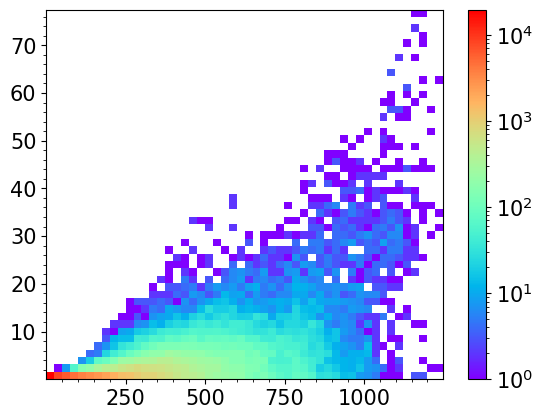

In [42]:
plt.hist2d(np.sqrt(atm[8,6,:,:,100]**2+atm[8,7,:,:,100]**2).flatten(),np.abs(S[8,:,:,100].flatten()/1e9),bins=50,norm=colors.LogNorm(),cmap='rainbow')
plt.colorbar()
#plt.ylim([0,40])

In [38]:
np.mean(atm[8,0,:,:,95])

0.3268520102212431

(0.0, 1250.0)

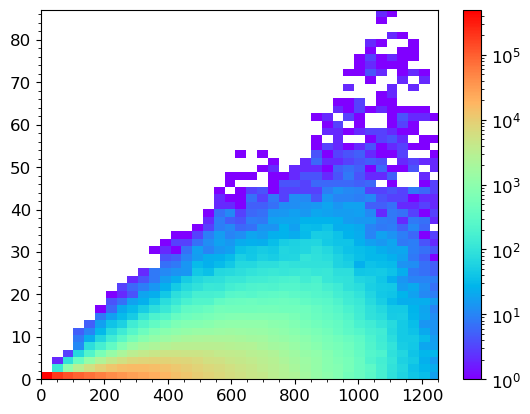

In [101]:
plt.hist2d(np.sqrt(atm[:,6,:,:,100]**2+atm[:,7,:,:,100]**2).flatten(),np.abs(S[:,:,:,100].flatten()/1e9),bins=50,norm=colors.LogNorm(),cmap='rainbow')
plt.colorbar()
plt.xlim([0,1250])
#plt.ylim([0,40])

In [46]:
t = np.arange(20)*14.3

Text(0.5, 0, 't [s]')

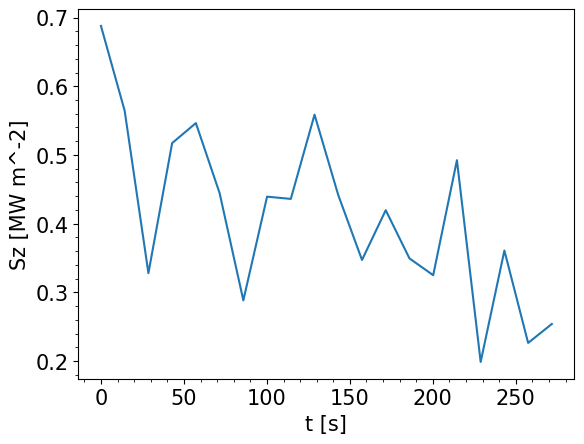

In [58]:
plt.plot(t,np.mean(S_tau[:,:,:,20]/1e9,axis=(1,2)))
plt.ylabel('Sz [MW m^-2]')
plt.xlabel('t [s]')

Text(0.5, 0, 't [s]')

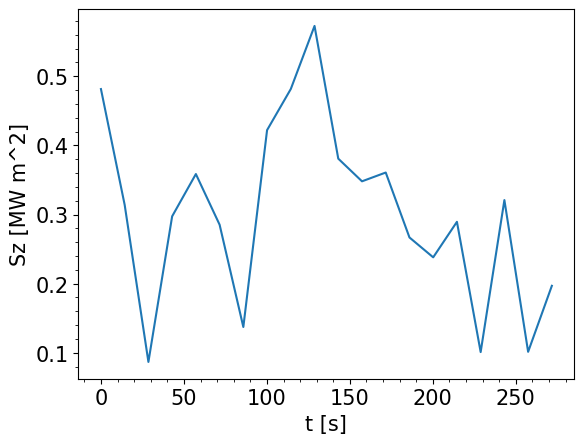

In [ ]:
plt.plot(t,np.mean(S[:,:,:,100]/1e9,axis=(1,2)))
plt.ylabel('Sz [MW m^-2]')
plt.xlabel('t [s]')

In [66]:
np.mean(atm_tau[6,8,:,:,10])

599.9118271425948

In [53]:
positives = S[6,:,:,100][S[6,:,:,100]>1e6]
negatives = S[6,:,:,100][S[6,:,:,100]<-1e6]

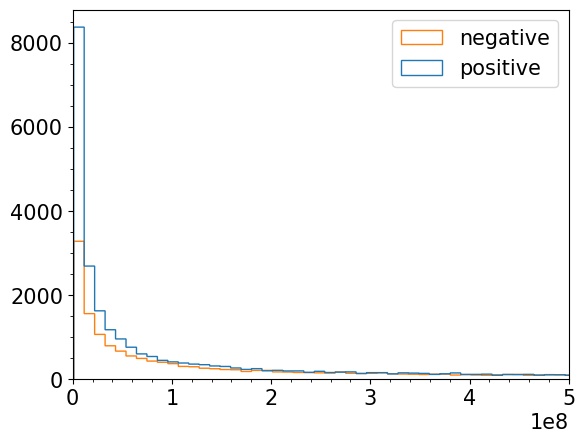

In [64]:
plt.hist([positives, -negatives],bins=5000,histtype='step',label=['positive','negative'])
plt.xlim([0,5e8])
#plt.ylim([0,2000])
plt.legend()


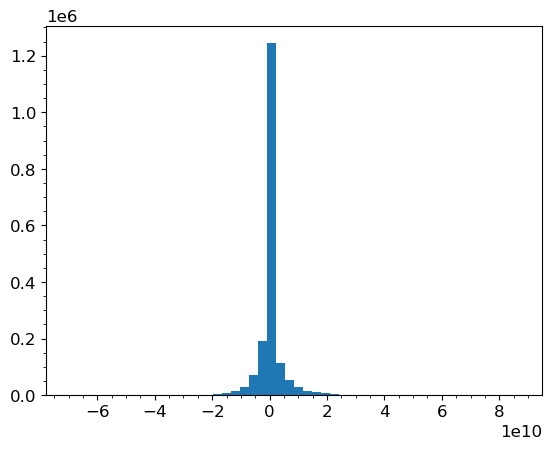

In [188]:
plt.hist(S[:,:,:,100].flatten(),bins=50)
plt.show()

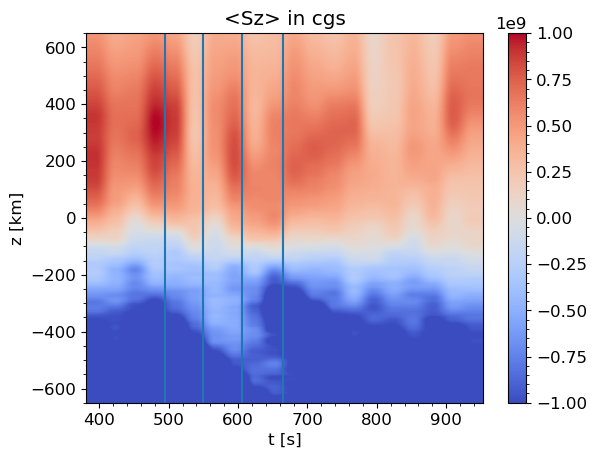

In [169]:
plt.imshow(np.mean(S[:,:,:,:],axis=(1,2)).T,origin='lower',cmap='coolwarm',vmin=-1e9,vmax=1e9,extent=[381,381+20*2*14.3,0-100*6.5,200*6.5-100*6.5],aspect='auto')
plt.colorbar()
plt.xlabel('t [s]')
plt.ylabel('z [km]')
plt.title('<Sz> in cgs')
plt.axvline(495)
plt.axvline(550)
plt.axvline(606)
plt.axvline(665)

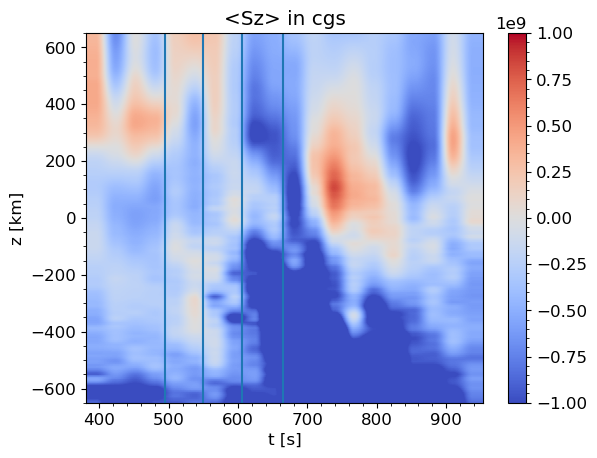

In [160]:
plt.imshow(np.mean(S[:,120:220,50:150,:],axis=(1,2)).T,origin='lower',cmap='coolwarm',vmin=-1e9,vmax=1e9,extent=[381,381+20*2*14.3,0-100*6.5,200*6.5-100*6.5],aspect='auto')
plt.colorbar()
plt.xlabel('t [s]')
plt.ylabel('z [km]')
plt.title('<Sz> in cgs')
plt.axvline(495)
plt.axvline(550)
plt.axvline(606)
plt.axvline(665)

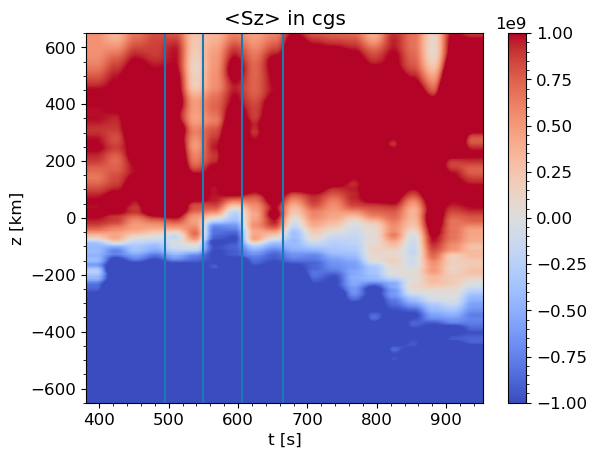

In [170]:
plt.imshow(np.mean(S[:,oppo[:,0],oppo[:,1],:],axis=1).T,origin='lower',cmap='coolwarm',vmin=-1e9,vmax=1e9,extent=[381,381+20*2*14.3,0-100*6.5,200*6.5-100*6.5],aspect='auto')
plt.colorbar()
plt.xlabel('t [s]')
plt.ylabel('z [km]')
plt.title('<Sz> in cgs')
plt.axvline(495)
plt.axvline(550)
plt.axvline(606)
plt.axvline(665)

## Lorentz force

$ f = J \times B$ \
$ J = \frac{1}{4\pi} (\nabla \times B) $ \
$ J_x = \frac{1}{4\pi} (\frac{\partial B_z}{\partial y}-\frac{\partial B_y}{\partial z}) $

In [8]:
Jx = (np.gradient(atm[:,8,:,:,:],6.5,axis=2) - np.gradient(atm[:,7,:,:,:],6.5,axis=3)) / (4*np.pi)
Jy = (np.gradient(atm[:,6,:,:,:],6.5,axis=3) - np.gradient(atm[:,8,:,:,:],6.5,axis=1)) / (4*np.pi)
Jz = (np.gradient(atm[:,7,:,:,:],6.5,axis=1) - np.gradient(atm[:,6,:,:,:],6.5,axis=2)) / (4*np.pi)

In [9]:
fx = Jy* atm[:,8,:,:,:] - Jz* atm[:,7,:,:,:]
fy = Jz* atm[:,6,:,:,:] - Jx* atm[:,8,:,:,:]
fz = Jx* atm[:,7,:,:,:] - Jy* atm[:,6,:,:,:]


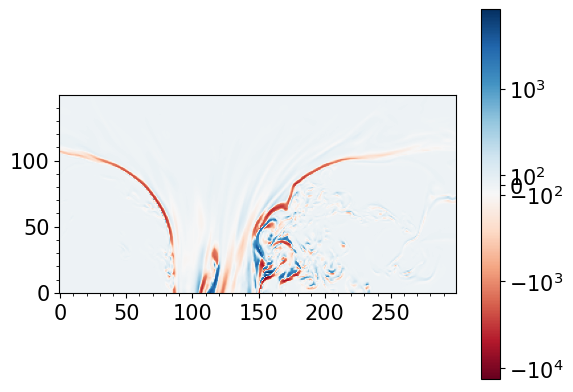

In [53]:
plt.imshow(fz[8,:,118,50:].T,origin='lower',cmap='RdBu',norm=colors.SymLogNorm(linthresh=1e3))
plt.colorbar()

## magnetic flux

In [5]:
t = np.arange(20)*14.3

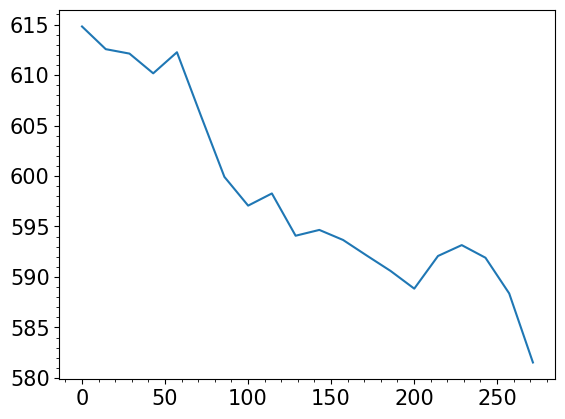

In [6]:
plt.plot(t,np.mean(atm_tau[:,8,:,:,10],axis=(1,2)))

In [10]:
160*1.43

228.79999999999998

In [11]:
230+270

500

In [ ]:
muramdir = '/dat/milic/MURaM_400G_plage_pore/'
slice = np.memmap(muramdir+'2D/Pore_10Mm_6x6km_res_Bz400G_tau_1.000_bx_012000_to_044450.dat',dtype=np.float32,mode='r',shape=(650,1536,1536))
slice = slice*np.sqrt(4*np.pi)

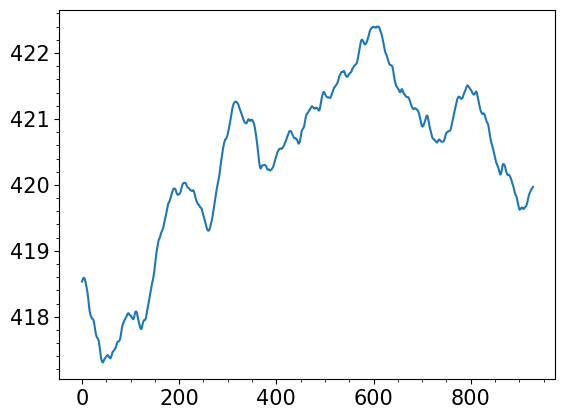

In [13]:
t = np.arange(650)*1.43
plt.plot(t,np.mean(slice[:,:,:],axis=(1,2)))

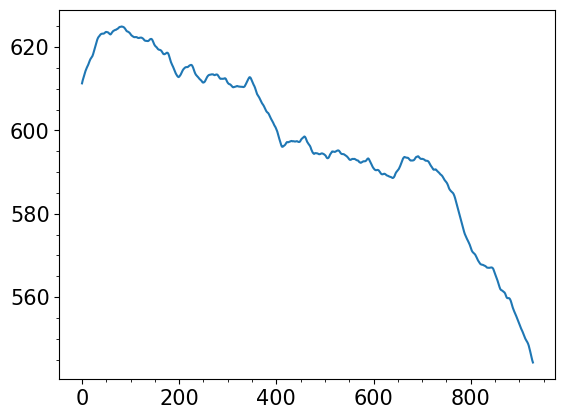

In [16]:
plt.plot(t,np.mean(slice[:,850:1150,650:950],axis=(1,2)))

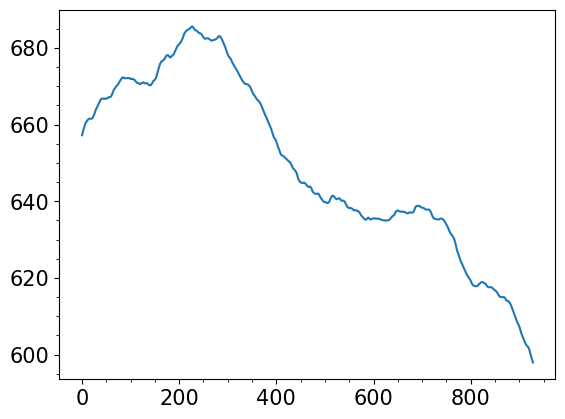

In [ ]:
plt.plot(t,np.mean(np.abs(slice[:,850:1150,650:950]),axis=(1,2)))

## Kinetic Energy

$< \frac{1}{2}\rho v^2>$ (t)

In [10]:
K = atm[:,9,:,:,:] * (atm[:,3,:,:,:]**2+atm[:,4,:,:,:]**2+atm[:,5,:,:,:]**2)/2

## Magnetic energy
$<\frac{B^2}{8 \pi}>$ (t)

In [11]:
M = (atm[:,6,:,:,:]**2+atm[:,7,:,:,:]**2+atm[:,8,:,:,:]**2)/(8*np.pi)

In [38]:
t = np.arange(40)*14.3+381

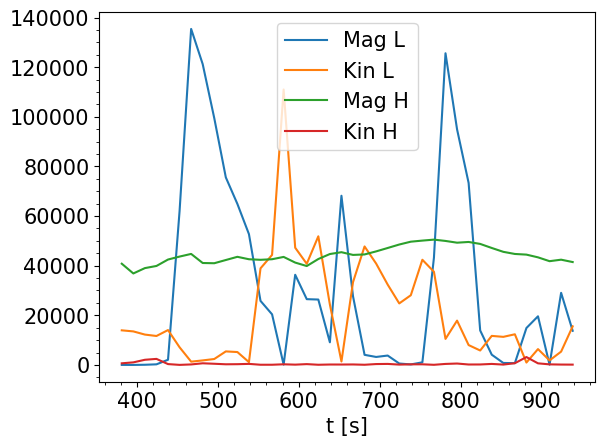

In [46]:
x = 160
y = 118
plt.plot(t,M[:,x,y,100],label='Mag L')
plt.plot(t,K[:,x,y,100],label='Kin L')
plt.plot(t,M[:,x,y,130],label='Mag H')
plt.plot(t,K[:,x,y,130],label='Kin H')
plt.xlabel('t [s]')
plt.legend()

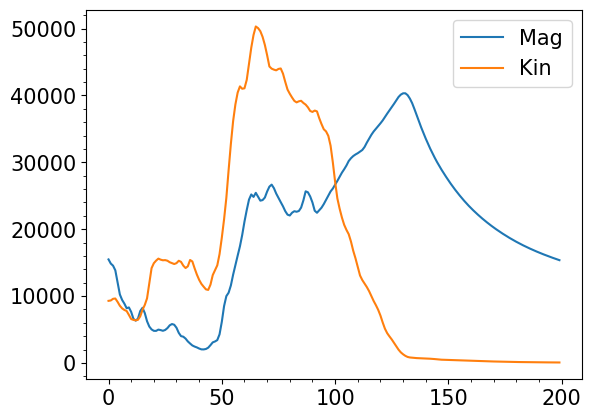

In [45]:
plt.plot(np.mean(M[16,150:180,100:130,:],axis=(0,1)),label='Mag')
plt.plot(np.mean(K[16,150:180,100:130,:],axis=(0,1)),label='Kin')
plt.legend()

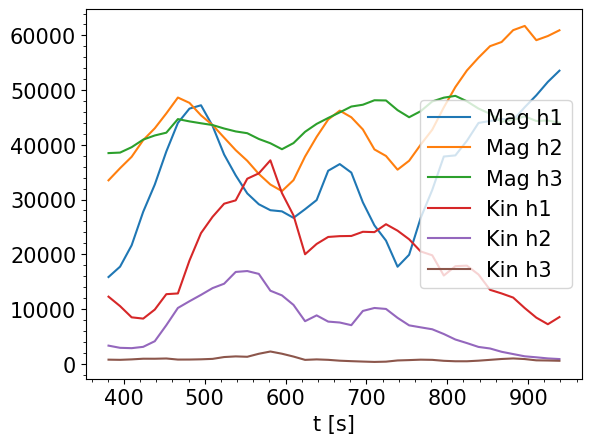

In [39]:
plt.plot(t,np.mean(M[:,150:180,100:130,100],axis=(1,2)),label='Mag h1')
plt.plot(t,np.mean(M[:,150:180,100:130,115],axis=(1,2)),label='Mag h2')
plt.plot(t,np.mean(M[:,150:180,100:130,130],axis=(1,2)),label='Mag h3')
plt.plot(t,np.mean(K[:,150:180,100:130,100],axis=(1,2)),label='Kin h1')
plt.plot(t,np.mean(K[:,150:180,100:130,115],axis=(1,2)),label='Kin h2')
plt.plot(t,np.mean(K[:,150:180,100:130,130],axis=(1,2)),label='Kin h3')
plt.xlabel('t [s]')
plt.legend()

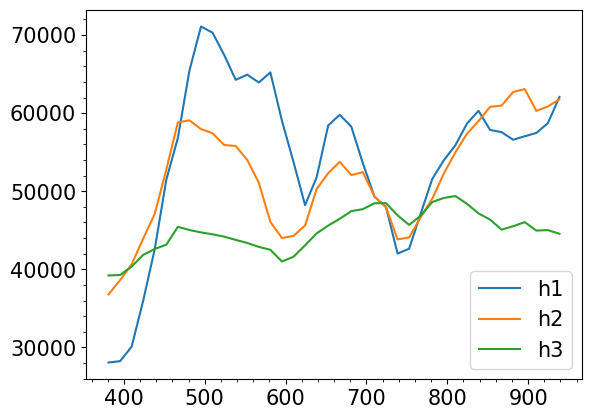

In [41]:
plt.plot(t,np.mean((M+K)[:,150:180,100:130,100],axis=(1,2)),label='h1')
plt.plot(t,np.mean((M+K)[:,150:180,100:130,115],axis=(1,2)),label='h2')
plt.plot(t,np.mean((M+K)[:,150:180,100:130,130],axis=(1,2)),label='h3')
plt.legend()

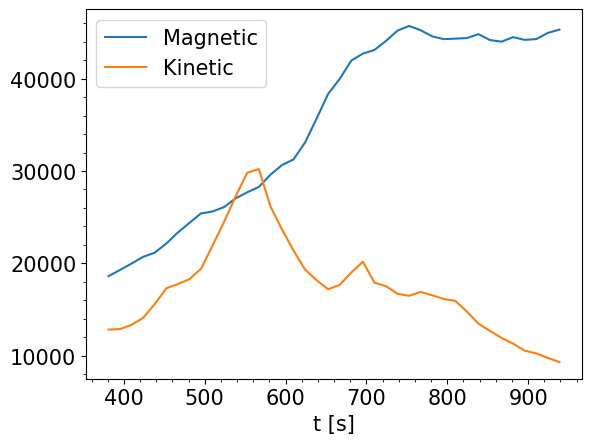

In [48]:
plt.plot(t,np.mean(M[:,120:220,50:150,100],axis=(1,2)),label='Magnetic')
plt.plot(t,np.mean(K[:,120:220,50:150,100],axis=(1,2)),label='Kinetic')
plt.xlabel('t [s]')
plt.legend()


## test

In [ ]:
slice = 

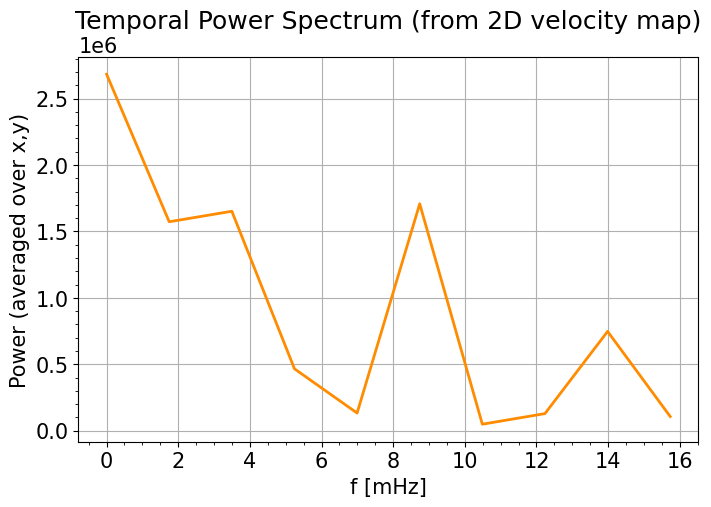

Dominant angular frequency ω ≈ 0.000e+00 rad/s
Expected ω = 1.885e-02 rad/s


In [75]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Create a synthetic velocity cube: v(x, y, t) ---
#nx, ny = 64, 64        # spatial grid
nt = 20                # number of time steps
dt = 14.3*2               # time cadence [s] (e.g., HMI = 45 sec)
#t = np.arange(nt) * dt  # time array

# Simulate an oscillation with a known frequency
freq = 3.0e-3  # Hz (3 mHz, typical solar p-mode)
omega_true = 2 * np.pi * freq

# Create a wave pattern that oscillates in time and space
kx, ky = 0.1, 0.05  # spatial wave numbers [1/Mm, arbitrary units]
#x = np.arange(nx)
#y = np.arange(ny)
#X, Y = np.meshgrid(x, y)

#v = np.zeros((ny, nx, nt))
#for i, ti in enumerate(t):
#    v[:, :, i] = np.sin(kx * X + ky * Y + omega_true * ti)

# --- 2. Compute the temporal FFT for each pixel ---
#v_fft = np.fft.fft(atm[:,5,:,:,100], axis=0)
v_fft = np.fft.fft(atm_tau[:,8,160,118,10], axis=0)
freqs = np.fft.fftfreq(nt, dt)  # temporal frequencies (Hz)
omega = 2 * np.pi * freqs       # angular frequency (rad/s)

# --- 3. Compute the power spectrum (average over space) ---
#power_spectrum = np.mean(np.abs(v_fft)**2, axis=(0,1))
power_spectrum = np.abs(v_fft)**2
half = nt // 2                  # keep positive frequencies
omega_pos = omega[:half]
power_pos = power_spectrum[:half]
freqs_pos = freqs[:half] *1e3


# --- 4. Plot the temporal power spectrum ---
plt.figure(figsize=(8,5))
plt.plot(freqs_pos, power_pos, color='darkorange', lw=2)
plt.xlabel(r'f [mHz]')
plt.ylabel('Power (averaged over x,y)')
plt.title('Temporal Power Spectrum (from 2D velocity map)')
plt.grid(True)
plt.show()

# --- 5. Find the dominant ω ---
dominant_idx = np.argmax(power_pos)
print(f"Dominant angular frequency ω ≈ {omega_pos[dominant_idx]:.3e} rad/s")
print(f"Expected ω = {omega_true:.3e} rad/s")
